# 09 - Multi-Layer Perceptron (MLP) Neural Network

## Diabetic Foot Ulcer Risk Classification - MLP Model

This notebook trains a Multi-Layer Perceptron neural network for early diabetic foot ulcer detection using multi-sensor wearable data.

### Objectives:
- Preprocess data with feature engineering
- Train MLP neural network classifier
- Evaluate model performance
- Export model as .pkl and .tflite for mobile deployment

In [17]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Create directories if they don't exist
os.makedirs('models', exist_ok=True)
os.makedirs('models/MLP', exist_ok=True)
os.makedirs('plots', exist_ok=True)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 1. Load Dataset

In [18]:
# Load the dataset
DATA_PATH = '../Synthetic_Data/synthetic_foot_ulcer_dataset_RISK.csv'
df = pd.read_csv(DATA_PATH)

print(f"✅ Dataset loaded: {df.shape[0]} samples × {df.shape[1]} columns")
df.head()

✅ Dataset loaded: 10000 samples × 20 columns


,temp_heel,press_heel,temp_ball,press_ball,temp_arch,press_arch,temp_toe,press_toe,spo2,heartRate,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,stepCount,batteryLevel,risk_score,label
0,33.498160,58.028572,34.927976,43.946339,32.624075,26.239781,32.232334,54.647046,95.621089,81,0.239495,-0.478550,9.866665,-34.223433,-42.545393,-9.398040,59,99,0.378454,0
1,32.931085,23.624257,34.473544,35.298480,35.932924,38.670516,35.439762,47.212302,85.198974,119,-6.080159,3.358271,12.137578,-88.087821,90.418256,29.849513,34,97,0.693139,1
2,33.564242,27.289444,35.021446,37.006235,32.831767,42.708013,32.125253,53.691391,90.927254,73,-2.721560,3.565877,12.156596,212.480807,21.078883,131.341689,23,45,0.555218,0
3,35.861021,44.281370,33.103997,31.850940,40.354115,105.342867,33.693606,35.795261,95.935108,92,2.095321,0.520806,11.786854,19.289773,-13.456407,93.181492,32,67,0.662824,1
4,33.483273,46.753650,34.663689,43.651912,33.098887,42.449737,33.531707,58.868484,95.825943,73,10.116889,-2.761172,8.604085,-4.869127,-113.500037,83.399329,95,23,0.388919,0


## 2. Feature Definition

### Features to INCLUDE:
- Temperature sensors (4): temp_heel, temp_ball, temp_arch, temp_toe
- Pressure sensors (4): press_heel, press_ball, press_arch, press_toe
- Vital signs (2): spo2, heartRate
- Activity (1): stepCount

### Features to EXCLUDE:
- `batteryLevel`: System-level feature
- `risk_score`: Model output, NOT input
- Motion sensors (6): acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z (NOT available in BLE transmission)
- Engineered motion features: acc_magnitude, gyro_magnitude (derived from unavailable sensors)

In [19]:
# Define feature groups
TEMP_FEATURES = ['temp_heel', 'temp_ball', 'temp_arch', 'temp_toe']
PRESSURE_FEATURES = ['press_heel', 'press_ball', 'press_arch', 'press_toe']
VITAL_FEATURES = ['spo2', 'heartRate']
ACTIVITY_FEATURES = ['stepCount']

# All raw sensor features (WITHOUT motion sensors - not available in BLE)
RAW_SENSOR_FEATURES = (TEMP_FEATURES + PRESSURE_FEATURES + VITAL_FEATURES + 
                       ACTIVITY_FEATURES)

# Target column
TARGET = 'label'

print(f"Raw sensor features ({len(RAW_SENSOR_FEATURES)}): {RAW_SENSOR_FEATURES}")

Raw sensor features (11): ['temp_heel', 'temp_ball', 'temp_arch', 'temp_toe', 'press_heel', 'press_ball', 'press_arch', 'press_toe', 'spo2', 'heartRate', 'stepCount']


## 3. Feature Engineering

In [20]:
# Create a copy for feature engineering
df_processed = df.copy()

# =============================================================================
# ENGINEERED FEATURES
# =============================================================================

# Pressure features
df_processed['max_pressure'] = df_processed[PRESSURE_FEATURES].max(axis=1)
df_processed['pressure_variance'] = df_processed[PRESSURE_FEATURES].var(axis=1)

# Temperature features
df_processed['max_temp'] = df_processed[TEMP_FEATURES].max(axis=1)
df_processed['temp_variance'] = df_processed[TEMP_FEATURES].var(axis=1)

# Define engineered features (WITHOUT motion-derived features)
ENGINEERED_FEATURES = [
    'max_pressure', 'pressure_variance',
    'max_temp', 'temp_variance'
]

print(f"Engineered features created: {ENGINEERED_FEATURES}")
df_processed[ENGINEERED_FEATURES].describe()

Engineered features created: ['max_pressure', 'pressure_variance', 'max_temp', 'temp_variance']


,max_pressure,pressure_variance,max_temp,temp_variance
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,64.596223,359.000757,36.376418,3.301407
std,21.680199,431.893589,1.989464,3.612137
min,24.814384,0.256188,32.280170,0.002370
25%,50.888792,92.210175,35.082359,0.899668
50%,56.688439,175.441829,35.664349,1.729986
75%,76.954200,417.771393,37.997981,4.628611
max,119.986875,2236.700968,40.996875,17.289692


In [21]:
# Combine all features for model
ALL_FEATURES = RAW_SENSOR_FEATURES + ENGINEERED_FEATURES

print(f"\n{'='*80}")
print("FINAL FEATURE SET FOR MODEL TRAINING")
print(f"{'='*80}")
print(f"\nTotal features: {len(ALL_FEATURES)}")
print(f"\nRaw sensor features ({len(RAW_SENSOR_FEATURES)}):")
for i, f in enumerate(RAW_SENSOR_FEATURES, 1):
    print(f"  {i:2d}. {f}")
    
print(f"\nEngineered features ({len(ENGINEERED_FEATURES)}):")
for i, f in enumerate(ENGINEERED_FEATURES, 1):
    print(f"  {i:2d}. {f}")


FINAL FEATURE SET FOR MODEL TRAINING

Total features: 15

Raw sensor features (11):
   1. temp_heel
   2. temp_ball
   3. temp_arch
   4. temp_toe
   5. press_heel
   6. press_ball
   7. press_arch
   8. press_toe
   9. spo2
  10. heartRate
  11. stepCount

Engineered features (4):
   1. max_pressure
   2. pressure_variance
   3. max_temp
   4. temp_variance


## 4. Prepare Features and Target

In [22]:
# Separate features (X) and target (y)
X = df_processed[ALL_FEATURES].copy()
y = df_processed[TARGET].copy()

print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts())

Feature matrix X shape: (10000, 15)
Target vector y shape: (10000,)

Class distribution:
label
0    6692
1    3308
Name: count, dtype: int64


In [23]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

Training set: 8000 samples
Test set: 2000 samples

Training class distribution:
label
0    5354
1    2646
Name: count, dtype: int64

Test class distribution:
label
0    1338
1     662
Name: count, dtype: int64


## 5. Feature Scaling

In [24]:
# Initialize and fit scaler
scaler = StandardScaler()

# Fit on training data only, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for inspection
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=ALL_FEATURES)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=ALL_FEATURES)

print("✅ Features scaled using StandardScaler")
print("\nScaled training data statistics:")
print(X_train_scaled_df.describe().loc[['mean', 'std']].round(4))

✅ Features scaled using StandardScaler

Scaled training data statistics:
      temp_heel  temp_ball  temp_arch  temp_toe  press_heel  press_ball  \
mean     0.0000     0.0000    -0.0000    0.0000     -0.0000      0.0000   
std      1.0001     1.0001     1.0001    1.0001      1.0001      1.0001   

      press_arch  press_toe    spo2  heartRate  stepCount  max_pressure  \
mean     -0.0000     0.0000  0.0000     0.0000    -0.0000        0.0000   
std       1.0001     1.0001  1.0001     1.0001     1.0001        1.0001   

      pressure_variance  max_temp  temp_variance  
mean             0.0000    0.0000         0.0000  
std              1.0001    1.0001         1.0001  


## 6. Build and Train MLP Neural Network

In [25]:
# Build MLP model
mlp_model = keras.Sequential([
    keras.layers.Input(shape=(len(ALL_FEATURES),)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ MLP model architecture:")
mlp_model.summary()

✅ MLP model architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,697 (53.50 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [26]:
# Train the model
print("Training MLP Neural Network...")

history = mlp_model.fit(
    X_train_scaled, 
    y_train.values,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    verbose=0,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7
        )
    ]
)

print("✅ Model training complete!")

Training MLP Neural Network...
✅ Model training complete!


## 7. Model Evaluation

In [27]:
# Make predictions
y_pred_proba = mlp_model.predict(X_test_scaled, verbose=0).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n{'='*80}")
print("MODEL EVALUATION METRICS")
print(f"{'='*80}")
print(f"\n  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")


MODEL EVALUATION METRICS

  Accuracy:  0.9320
  Precision: 0.9009
  Recall:    0.8927
  F1-Score:  0.8968
  ROC-AUC:   0.9816


In [28]:
# Classification report
print(f"\n{'='*80}")
print("CLASSIFICATION REPORT")
print(f"{'='*80}")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'High Risk (1)']))


CLASSIFICATION REPORT
               precision    recall  f1-score   support

   Normal (0)       0.95      0.95      0.95      1338
High Risk (1)       0.90      0.89      0.90       662

     accuracy                           0.93      2000
    macro avg       0.92      0.92      0.92      2000
 weighted avg       0.93      0.93      0.93      2000



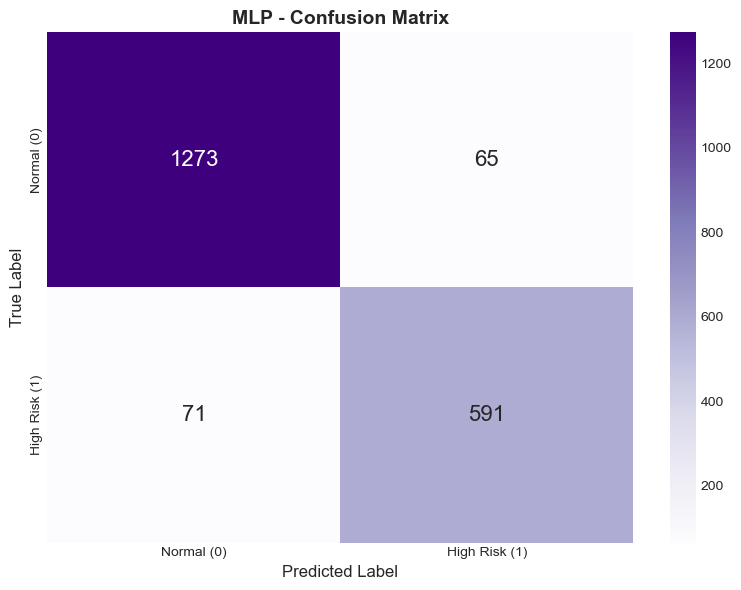

📊 Plot saved: plots/mlp_confusion_matrix.png


In [29]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Normal (0)', 'High Risk (1)'],
            yticklabels=['Normal (0)', 'High Risk (1)'],
            annot_kws={'size': 16}, ax=ax)

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('MLP - Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/mlp_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Plot saved: plots/mlp_confusion_matrix.png")

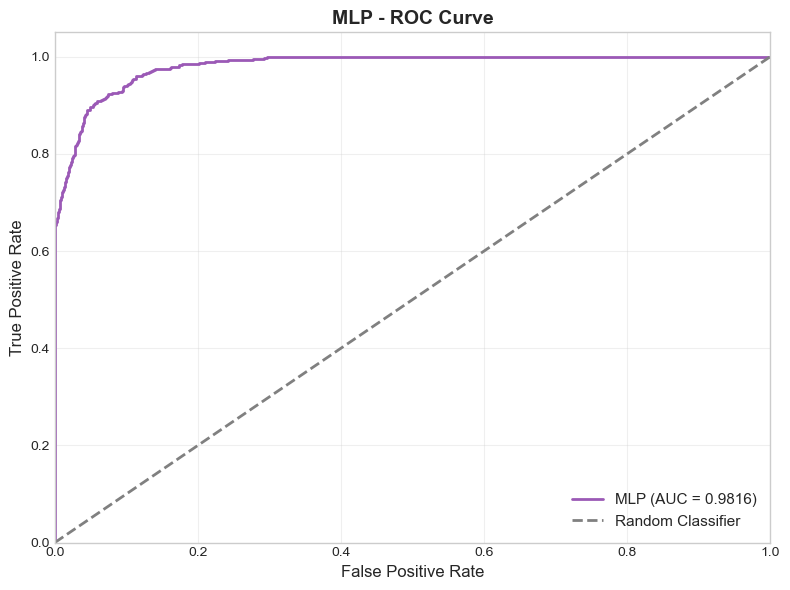

📊 Plot saved: plots/mlp_roc_curve.png


In [30]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#9b59b6', lw=2, label=f'MLP (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('MLP - ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/mlp_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Plot saved: plots/mlp_roc_curve.png")

## 8. Training History Visualization

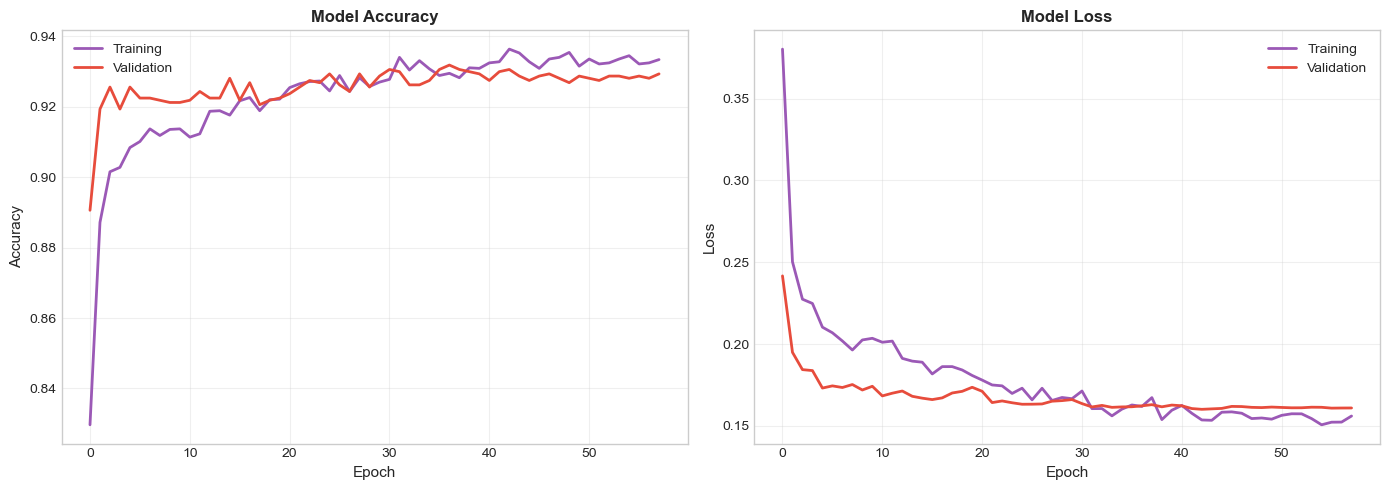

📊 Plot saved: plots/mlp_training_history.png


In [31]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training', color='#9b59b6', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', color='#e74c3c', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Training', color='#9b59b6', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('Model Loss', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/mlp_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Plot saved: plots/mlp_training_history.png")

## 9. Feature Importance (Permutation-based)

In [32]:
# Create wrapper for permutation importance
class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model
    
    def fit(self, X, y):
        """Dummy fit method for sklearn compatibility"""
        return self
    
    def predict(self, X):
        pred_proba = self.model.predict(X, verbose=0)
        return (pred_proba.flatten() >= 0.5).astype(int)
    
    def score(self, X, y):
        return accuracy_score(y, self.predict(X))

# Calculate permutation importance
print("Calculating permutation importance...")
wrapper = KerasClassifierWrapper(mlp_model)
perm_importance = permutation_importance(
    wrapper, X_test_scaled, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# Create DataFrame for feature importance
feature_importance = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': perm_importance.importances_mean
}).sort_values('importance', ascending=False)

print(f"\n{'='*80}")
print("FEATURE IMPORTANCE RANKING (Permutation-based)")
print(f"{'='*80}")
print(feature_importance.to_string(index=False))

Calculating permutation importance...

FEATURE IMPORTANCE RANKING (Permutation-based)
          feature  importance
             spo2     0.17840
        stepCount     0.06610
    temp_variance     0.03665
         max_temp     0.03600
     max_pressure     0.02950
        temp_arch     0.01300
        temp_ball     0.01300
        press_toe     0.01285
       press_ball     0.01125
pressure_variance     0.00945
        temp_heel     0.00925
         temp_toe     0.00830
       press_arch     0.00810
       press_heel     0.00780
        heartRate     0.00200


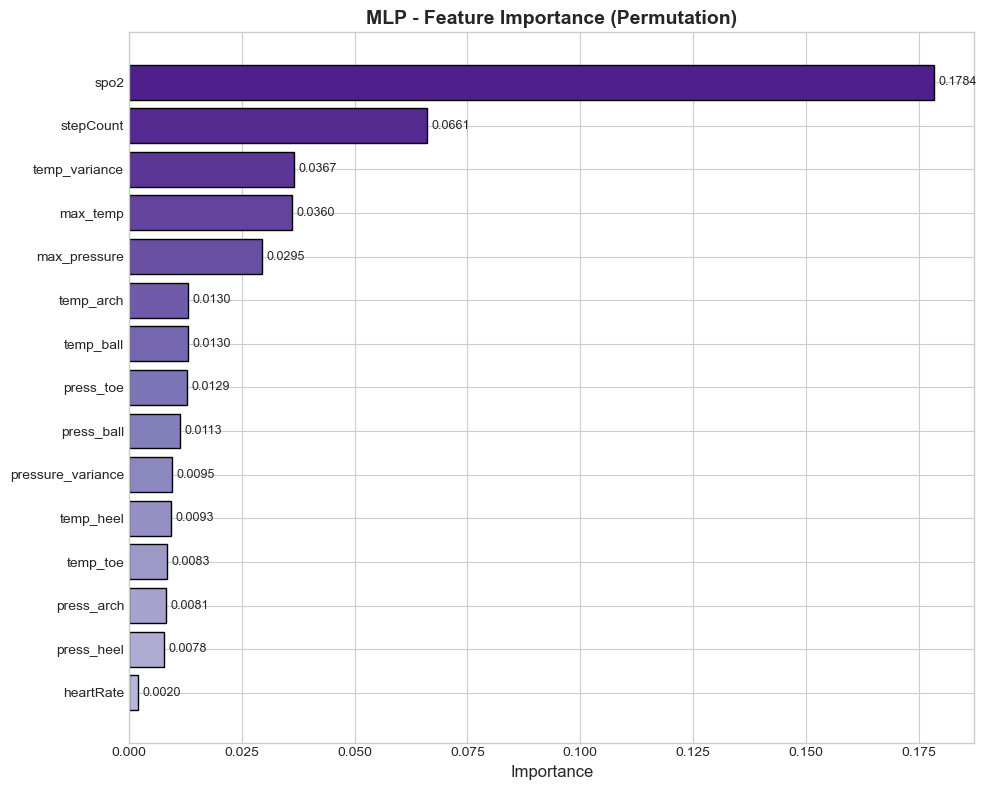

📊 Plot saved: plots/mlp_feature_importance.png


In [33]:
# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 8))

colors = plt.cm.Purples(np.linspace(0.4, 0.9, len(feature_importance)))
bars = ax.barh(feature_importance['feature'], feature_importance['importance'], 
               color=colors[::-1], edgecolor='black')

ax.set_xlabel('Importance', fontsize=12)
ax.set_title('MLP - Feature Importance (Permutation)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for bar, val in zip(bars, feature_importance['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plots/mlp_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Plot saved: plots/mlp_feature_importance.png")

## 10. Save Model (.pkl and .keras)

In [34]:
# Save the Keras model
KERAS_MODEL_PATH = 'models/MLP/mlp_model.keras'
mlp_model.save(KERAS_MODEL_PATH)
print(f"✅ Keras model saved: {KERAS_MODEL_PATH}")

# Save the scaler
SCALER_PATH = 'models/MLP/scaler.pkl'
joblib.dump(scaler, SCALER_PATH)
print(f"✅ Scaler saved: {SCALER_PATH}")

# Save feature list
FEATURES_PATH = 'models/MLP/feature_names.pkl'
joblib.dump(ALL_FEATURES, FEATURES_PATH)
print(f"✅ Feature names saved: {FEATURES_PATH}")

✅ Keras model saved: models/MLP/mlp_model.keras
✅ Scaler saved: models/MLP/scaler.pkl
✅ Feature names saved: models/MLP/feature_names.pkl


## 11. TensorFlow Lite Conversion

In [35]:
# Convert to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(mlp_model)

# Optimization for mobile
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

# Convert
tflite_model = converter.convert()

# Save TFLite model
TFLITE_PATH = 'models/MLP/mlp_model.tflite'
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

print(f"✅ TFLite model saved: {TFLITE_PATH}")
print(f"   Model size: {len(tflite_model) / 1024:.2f} KB")

INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmp85id64h0\assets


INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmp85id64h0\assets


Saved artifact at 'C:\Users\HP\AppData\Local\Temp\tmp85id64h0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 15), dtype=tf.float32, name='keras_tensor_11')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1952898648784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1952898648592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1952898650512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1952898651472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1952898651280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1952898650704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1952898651088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1952898650320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1952898650128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1952898652624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1952898652432:

In [36]:
# Verify TFLite model
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"\n{'='*80}")
print("TFLITE MODEL VERIFICATION")
print(f"{'='*80}")
print(f"\nInput shape: {input_details[0]['shape']}")
print(f"Input type: {input_details[0]['dtype']}")
print(f"Output shape: {output_details[0]['shape']}")
print(f"Output type: {output_details[0]['dtype']}")


TFLITE MODEL VERIFICATION

Input shape: [ 1 15]
Input type: <class 'numpy.float32'>
Output shape: [1 1]
Output type: <class 'numpy.float32'>


In [37]:
# Test TFLite inference
def tflite_predict(interpreter, input_data):
    """Run inference on TFLite model"""
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()
    
    interpreter.set_tensor(input_details[0]['index'], input_data.astype(np.float32))
    interpreter.invoke()
    
    return interpreter.get_tensor(output_details[0]['index'])

# Test with a sample
sample = X_test_scaled[:1].astype(np.float32)
tflite_output = tflite_predict(interpreter, sample)

print(f"\nSample TFLite inference:")
print(f"  Input shape: {sample.shape}")
print(f"  Output (risk probability): {tflite_output[0][0]:.4f}")
print(f"  Predicted class: {'High Risk' if tflite_output[0][0] >= 0.5 else 'Normal'}")


Sample TFLite inference:
  Input shape: (1, 15)
  Output (risk probability): 0.0000
  Predicted class: Normal


## 12. Inference Example (Risk Score Generation)

In [38]:
# Demonstrate how to generate risk score from model output
print(f"\n{'='*80}")
print("RISK SCORE GENERATION EXAMPLE")
print(f"{'='*80}")

# Get predictions from MLP
sample_indices = [0, 5, 10, 15, 20]
sample_data = X_test_scaled[sample_indices]

# Risk score = probability of class 1 (High Risk)
risk_scores = mlp_model.predict(sample_data, verbose=0).flatten()
predicted_classes = (risk_scores >= 0.5).astype(int)
actual_classes = y_test.iloc[sample_indices].values

print("\nSample predictions:")
print("-" * 60)
print(f"{'Index':<10} {'Risk Score':<15} {'Predicted':<15} {'Actual':<10}")
print("-" * 60)

for i, (idx, rs, pred, actual) in enumerate(zip(sample_indices, risk_scores, predicted_classes, actual_classes)):
    pred_label = 'High Risk' if pred == 1 else 'Normal'
    actual_label = 'High Risk' if actual == 1 else 'Normal'
    print(f"{idx:<10} {rs:<15.4f} {pred_label:<15} {actual_label:<10}")

print("\n📝 Note: Risk score is the model's probabilistic output (0.0 - 1.0)")
print("   - < 0.3: Low risk")
print("   - 0.3 - 0.6: Moderate risk")
print("   - > 0.6: High risk")


RISK SCORE GENERATION EXAMPLE

Sample predictions:
------------------------------------------------------------
Index      Risk Score      Predicted       Actual    
------------------------------------------------------------
0          0.0000          Normal          Normal    
5          0.0008          Normal          Normal    
10         0.0012          Normal          Normal    
15         0.9992          High Risk       High Risk 
20         0.0540          Normal          Normal    

📝 Note: Risk score is the model's probabilistic output (0.0 - 1.0)
   - < 0.3: Low risk
   - 0.3 - 0.6: Moderate risk
   - > 0.6: High risk


## 13. Summary

In [39]:
print(f"\n{'='*80}")
print("MLP NEURAL NETWORK MODEL - TRAINING COMPLETE")
print(f"{'='*80}")

print(f"\n📊 Model Performance:")
print(f"   - Accuracy:  {accuracy:.4f}")
print(f"   - Precision: {precision:.4f}")
print(f"   - Recall:    {recall:.4f}")
print(f"   - F1-Score:  {f1:.4f}")
print(f"   - ROC-AUC:   {roc_auc:.4f}")

print(f"\n📁 Saved Files:")
print(f"   - models/MLP/mlp_model.keras (Keras model)")
print(f"   - models/MLP/scaler.pkl (StandardScaler)")
print(f"   - models/MLP/feature_names.pkl (Feature list)")
print(f"   - models/MLP/mlp_model.tflite (TFLite model)")

print(f"\n📈 Plots:")
print(f"   - plots/mlp_confusion_matrix.png")
print(f"   - plots/mlp_roc_curve.png")
print(f"   - plots/mlp_training_history.png")
print(f"   - plots/mlp_feature_importance.png")

print(f"\n✅ MLP Neural Network pipeline complete!")


MLP NEURAL NETWORK MODEL - TRAINING COMPLETE

📊 Model Performance:
   - Accuracy:  0.9320
   - Precision: 0.9009
   - Recall:    0.8927
   - F1-Score:  0.8968
   - ROC-AUC:   0.9816

📁 Saved Files:
   - models/MLP/mlp_model.keras (Keras model)
   - models/MLP/scaler.pkl (StandardScaler)
   - models/MLP/feature_names.pkl (Feature list)
   - models/MLP/mlp_model.tflite (TFLite model)

📈 Plots:
   - plots/mlp_confusion_matrix.png
   - plots/mlp_roc_curve.png
   - plots/mlp_training_history.png
   - plots/mlp_feature_importance.png

✅ MLP Neural Network pipeline complete!


In [40]:
# Extract scaler values for Flutter integration
print(f"\n{'='*80}")
print("SCALER VALUES FOR FLUTTER INTEGRATION")
print(f"{'='*80}")

print(f"\nFeature means ({len(scaler.mean_)} values):")
print("List for Dart:")
print(f"const List<double> featureMeans = [")
for i, mean in enumerate(scaler.mean_):
    comma = "," if i < len(scaler.mean_) - 1 else ""
    print(f"  {mean:.15f}{comma}  // {ALL_FEATURES[i]}")
print(f"];")

print(f"\n\nFeature scales/stds ({len(scaler.scale_)} values):")
print("List for Dart:")
print(f"const List<double> featureStds = [")
for i, scale in enumerate(scaler.scale_):
    comma = "," if i < len(scaler.scale_) - 1 else ""
    print(f"  {1.0/scale:.15f}{comma}  // {ALL_FEATURES[i]}")
print(f"];")

print(f"\n\nDart Code Summary:")
print(f"Total features: {len(ALL_FEATURES)}")
print(f"Feature list: {ALL_FEATURES}")


SCALER VALUES FOR FLUTTER INTEGRATION

Feature means (15 values):
List for Dart:
const List<double> featureMeans = [
  34.377127267113607,  // temp_heel
  34.376776436691941,  // temp_ball
  34.384331094983494,  // temp_arch
  34.404600260634702,  // temp_toe
  44.134212921268379,  // press_heel
  43.937746057938966,  // press_ball
  43.832688437183343,  // press_arch
  44.349988690344688,  // press_toe
  92.488721981641774,  // spo2
  94.265249999999995,  // heartRate
  59.760500000000000,  // stepCount
  64.597849484194811,  // max_pressure
  358.746560145869012,  // pressure_variance
  36.387833158608558,  // max_temp
  3.330151855516803  // temp_variance
];


Feature scales/stds (15 values):
List for Dart:
const List<double> featureStds = [
  0.565352534871213,  // temp_heel
  0.560907760479280,  // temp_ball
  0.569056385618529,  // temp_arch
  0.547891185470064,  // temp_toe
  0.054544126291903,  // press_heel
  0.054640308757458,  // press_ball
  0.054551972382659,  // press_ar